In [16]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv

llm = ChatGroq(
    model = "llama-3.1-8b-instant"
)



In [17]:
from langchain_core.messages import HumanMessage

llm.invoke("what is cricket")



AIMessage(content="Cricket is a popular team sport played with a bat and ball on a rectangular field with two sets of three stumps (wickets) at each end. It is one of the most widely followed sports in the world, particularly in the Indian subcontinent, the UK, Australia, and the Caribbean.\n\nHere's a brief overview of the game:\n\n**Objective:**\nThe objective of cricket is to score runs by hitting the ball with the bat and running between the wickets, while the opposing team tries to stop them by getting the batsmen out.\n\n**Basic Rules:**\n\n1. **The Game:** A cricket match is divided into innings. Each team takes turns to bat and bowl. The batting team sends two batsmen onto the field, while the opposing team sends a bowler and a fielder.\n2. **Ways to Get Out:** A batsman can get out in several ways, including:\n\t* Bowled: When the ball hits the wickets and knocks them over.\n\t* Lbw (Leg Before Wicket): When the umpire thinks the ball would have hit the wickets if it hadn't be

In [18]:
from typing import TypedDict , List ,Annotated
from operator import add

class graph_schema(TypedDict):

    messages_manual: List
    messages_auto : Annotated[List,add] 

In [24]:
from langchain_core.messages import AIMessage

def create_post(state:graph_schema):
    
    state = dict(state)

    messages_manual = state['messages_manual']

    response_manual = llm.invoke(messages_manual).content
    response_manual_ai = AIMessage(content =response_manual)
    
    state['messages_manual'] =  messages_manual + [response_manual_ai]

    return state 



def curate_post(state:graph_schema):


    state = dict(state)

    messages_manual = state['messages_manual']

    response_manual = llm.invoke(messages_manual).content
    response_manual_ai = AIMessage(content =response_manual)

    state['messages_manual'] = messages_manual + [response_manual_ai]
    
    return state
    


In [25]:
from langgraph.graph import StateGraph , START , END

graph = StateGraph(graph_schema)

graph.add_node("create_post" , create_post)
graph.add_node("curate_post" , curate_post)

graph.add_edge(START , "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post" , END)

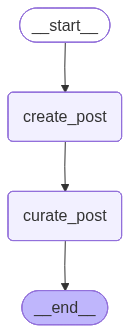

In [26]:
DGraph = graph.compile()
DGraph

In [27]:
DGraph.invoke(
    {
    "messages_manual":[HumanMessage(content = "What is cricket?")]
    }
)

{'messages_manual': [HumanMessage(content='What is cricket?', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Cricket is a popular team sport that originated in England in the 16th century. It is played with a bat and ball on a rectangular field with a flat surface, usually made of grass or turf. The objective of the game is to score runs by hitting the ball with a bat and running between two sets of three stumps (called wickets) while the opposing team tries to stop them.\n\nHere's a brief overview of how the game is played:\n\n**The Basics:**\n\n1. Two teams, each consisting of 11 players, take turns playing offense (batting) and defense (bowling and fielding).\n2. The batting team sends two batsmen onto the field, while the opposing team sends a bowler and 10 fielders.\n3. The bowler delivers the ball, which the batsman tries to hit with a bat.\n4. The batsman can score runs by hitting the ball and running between the wickets.\n5. The batting team continues to bat 